# Project 4 : Fed-batch Reactor

## Julian Barth, Arsenijs Danilko, Aloïsse Dantant-Cochet, Marin Desgeans, Robin Elkaim

## Exercise 1: Fed-Batch Bioreactor Simulation with Substrate Inhibition

We will simulate a semi-continuous fed-batch bioreactor with three phases:
- Initiation
- Processing
- Harvesting

We track:
- Biomass (X)
- Substrate (S)
- Product (P)
- Volume (V)

The system includes substrate inhibition kinetics.

## Model Equations

The specific growth rate with substrate inhibition is:

$$
\mu = \mu_{max} \cdot \frac{S}{K_S + S + \frac{S^2}{K_I}}
$$

Mass balances:

### Initiation
$$
\frac{dX}{dt} = \mu X V
$$
$$
\frac{dS}{dt} = F_I S_0 - \frac{\mu X V}{Y_{X/S}}
$$
$$
\frac{dP}{dt} = \frac{\mu X V}{Y_{X/P}}
$$
$$
\frac{dV}{dt} = F_I
$$

### Processing
$$
\frac{dX}{dt} = \mu X V
$$
$$
\frac{dS}{dt} = F_P S_P - \frac{\mu X V}{Y_{X/S}}
$$
$$
\frac{dP}{dt} = \frac{\mu X V}{Y_{X/P}}
$$
$$
\frac{dV}{dt} = F_P
$$

### Harvesting
$$
\frac{dX}{dt} = -F_H X + \mu X V
$$
$$
\frac{dS}{dt} = -F_H S - \frac{\mu X V}{Y_{X/S}}
$$
$$
\frac{dP}{dt} = -F_H P + \frac{\mu X V}{Y_{X/P}}
$$
$$
\frac{dV}{dt} = -F_H
$$

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
# Kinetic parameters
mu_max = 0.3       # h^-1
Ks = 0.8           # g/L
Ki = 100           # g/L

Yxs = 0.45
Yxp = 0.15

# Feed conditions
S0 = 80
Sp = 80

FI = 0.2
FP = 0.5
FH = 2.5

# Initial conditions
V0 = 0.85
X0 = 30 * V0   # mass = concentration * volume
S0_init = 0 * V0
P0 = 0

y0 = [X0, S0_init, P0, V0]

In [3]:
def mu(S, V):
    S_conc = S / V
    return mu_max * S_conc / (Ks + S_conc + (S_conc**2)/Ki)

In [4]:
def reactor(t, y):
    X, S, P, V = y
    
    m = mu(S, V)
    
    if t <= 1:  # Initiation
        dXdt = m * X
        dSdt = FI * S0 - (m * X) / Yxs
        dPdt = (m * X) / Yxp
        dVdt = FI
        
    elif t <= 6:  # Processing
        dXdt = m * X
        dSdt = FP * Sp - (m * X) / Yxs
        dPdt = (m * X) / Yxp
        dVdt = FP
        
    else:  # Harvesting
        dXdt = -FH * (X / V) + m * X
        dSdt = -FH * (S / V) - (m * X) / Yxs
        dPdt = -FH * (P / V) + (m * X) / Yxp
        dVdt = -FH
        
    return [dXdt, dSdt, dPdt, dVdt]

In [5]:
t_span = (0, 7)
t_eval = np.linspace(0, 7, 500)

sol = solve_ivp(reactor, t_span, y0, t_eval=t_eval)

In [6]:
X = sol.y[0]
S = sol.y[1]
P = sol.y[2]
V = sol.y[3]

Xc = X / V
Sc = S / V
Pc = P / V

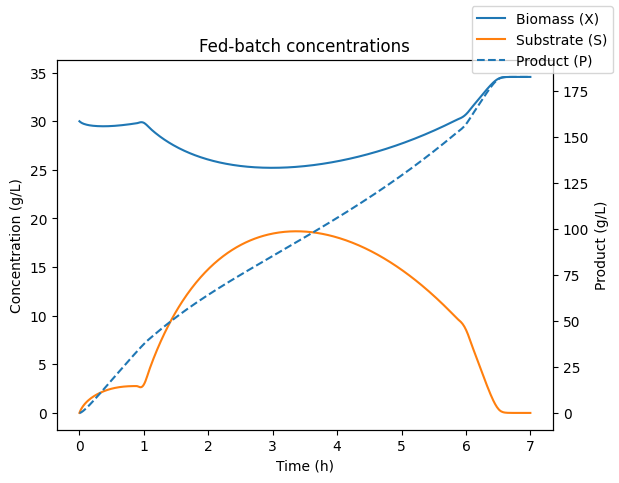

In [7]:
fig, ax1 = plt.subplots()

ax1.plot(sol.t, Xc, label='Biomass (X)')
ax1.plot(sol.t, Sc, label='Substrate (S)')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Concentration (g/L)')

ax2 = ax1.twinx()
ax2.plot(sol.t, Pc, linestyle='--', label='Product (P)')
ax2.set_ylabel('Product (g/L)')

fig.legend()
plt.title("Fed-batch concentrations")
plt.show()

## Part (b): Repeated Cycles Simulation

In this section, we simulate 10 complete cycles of:
Processing (5 h)
Harvesting (1 h)

The initiation phase is performed only once.

The system is assumed to reach a quasi steady-state after 10 cycles.

We compute:
Concentration profiles over time
Production rate at the 10th cycle

In [8]:
def reactor_processing(t, y):
    X, S, P, V = y
    m = mu(S, V)
    
    dXdt = m * X
    dSdt = FP * Sp - (m * X) / Yxs
    dPdt = (m * X) / Yxp
    dVdt = FP
    
    return [dXdt, dSdt, dPdt, dVdt]


def reactor_harvesting(t, y):
    X, S, P, V = y
    m = mu(S, V)
    
    dXdt = -FH * (X / V) + m * X
    dSdt = -FH * (S / V) - (m * X) / Yxs
    dPdt = -FH * (P / V) + (m * X) / Yxp
    dVdt = -FH
    
    return [dXdt, dSdt, dPdt, dVdt]

In [9]:
# Initiation phase (0 → 1 h)
t_init = np.linspace(0, 1, 100)

sol_init = solve_ivp(reactor, (0, 1), y0, t_eval=t_init)

# Initial state for cycles
y_current = sol_init.y[:, -1]

In [11]:
# Storage
t_total = list(sol_init.t)
X_total = list(sol_init.y[0])
S_total = list(sol_init.y[1])
P_total = list(sol_init.y[2])
V_total = list(sol_init.y[3])

time_offset = 1

harvested_P_10 = 0

for cycle in range(10):
    
    # --- Processing (5 h)
    t_proc = np.linspace(0, 5, 200)
    sol_proc = solve_ivp(reactor_processing, (0, 5), y_current, t_eval=t_proc)
    
    # Update time
    t_total.extend(sol_proc.t + time_offset)
    X_total.extend(sol_proc.y[0])
    S_total.extend(sol_proc.y[1])
    P_total.extend(sol_proc.y[2])
    V_total.extend(sol_proc.y[3])
    
    time_offset += 5
    y_current = sol_proc.y[:, -1]
    
    # --- Harvesting (1 h)
    t_harv = np.linspace(0, 1, 100)
    sol_harv = solve_ivp(reactor_harvesting, (0, 1), y_current, t_eval=t_harv)
    
    # Compute harvested product ONLY for cycle 10
    if cycle == 9:
        P_start = sol_harv.y[2][0]
        P_end = sol_harv.y[2][-1]
        harvested_P_10 = P_start - P_end
    
    # Update time
    t_total.extend(sol_harv.t + time_offset)
    X_total.extend(sol_harv.y[0])
    S_total.extend(sol_harv.y[1])
    P_total.extend(sol_harv.y[2])
    V_total.extend(sol_harv.y[3])
    
    time_offset += 1
    y_current = sol_harv.y[:, -1]

In [12]:
t_total = np.array(t_total)
X_total = np.array(X_total)
S_total = np.array(S_total)
P_total = np.array(P_total)
V_total = np.array(V_total)

Xc = X_total / V_total
Sc = S_total / V_total
Pc = P_total / V_total

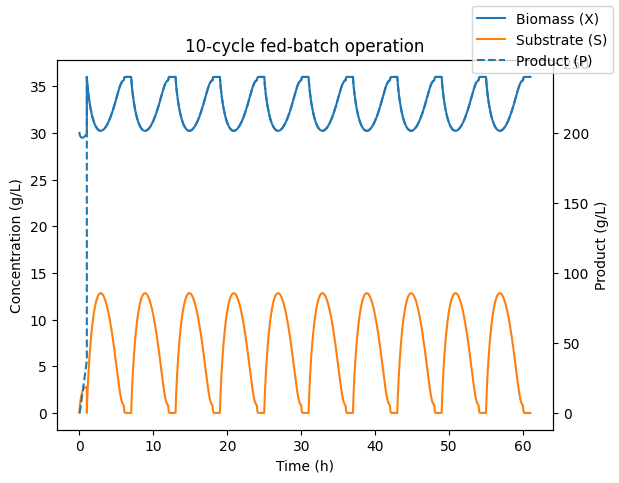

In [13]:
fig, ax1 = plt.subplots()

ax1.plot(t_total, Xc, label='Biomass (X)')
ax1.plot(t_total, Sc, label='Substrate (S)')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Concentration (g/L)')

ax2 = ax1.twinx()
ax2.plot(t_total, Pc, linestyle='--', label='Product (P)')
ax2.set_ylabel('Product (g/L)')

fig.legend()
plt.title("10-cycle fed-batch operation")
plt.show()

In [14]:
cycle_time = 6  # h

production_rate = harvested_P_10 / cycle_time

print("Production rate (g/h):", production_rate)

Production rate (g/h): 98.56624511280866


### Analysis of the 10-Cycle Operation

The simulation of 10 successive fed-batch cycles reveals a characteristic dynamic behavior typical of semi-continuous bioreactors.

### 1. Periodic Regime and Quasi-Steady State

After several cycles, the system exhibits a reproducible oscillatory pattern, indicating that a quasi steady-state has been reached.  
Each cycle behaves similarly to the previous one, which validates the assumption stated in the problem.



### 2. Substrate (S) and Biomass (X) Dynamics

The substrate and biomass concentrations display opposite oscillatory behaviors:

1.During the processing phase:
  - Substrate is continuously fed into the reactor
  - Biomass grows rapidly due to substrate availability
  - Substrate concentration tends to decrease due to consumption

2.During the harvesting phase:
  - Reactor content is partially removed
  - Both substrate and biomass concentrations drop
  - The dilution effect becomes dominant

This results in:
- Wave-like patterns for substrate concentration
- Inverse wave patterns for biomass

This reflects a competition between feeding, consumption, and dilution effects.


### 3. Product (P) Accumulation

The product concentration shows a distinct behavior:

During the first cycle, product accumulates significantly due to initially low dilution
In subsequent cycles, the product profile becomes periodic and closely follows biomass dynamics

This is expected since:
$$
\frac{dP}{dt} \propto \mu X
$$

Thus:
Product formation is directly linked to biomass growth
During harvesting, part of the product is removed, limiting long-term accumulation



### 4. Production Rate

The production rate at the 10th cycle is:

$$
\text{Production rate} = 98.57 \, \text{g/h}
$$

This value represents the amount of product harvested per unit time under cyclic steady operation.



### 5. Physical Interpretation

The system reaches a dynamic equilibrium where:

Product formation during processing
Product removal during harvesting

become balanced over each cycle.

This regime is desirable in industrial bioprocesses because:
It ensures predictable productivity
It allows continuous operation with controlled output


### 6. Key Insight

The oscillatory behavior is a direct consequence of the semi-continuous operation strategy:
Alternating feeding and harvesting phases
Coupled with nonlinear kinetics (substrate inhibition)

Such dynamics are typical of real fed-batch bioreactors and highlight the importance of cycle design in optimizing production.